In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import shutil

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading Landmarks

In [3]:
keypoints_loc = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/keypoints/keypoints_loc.txt'
keypoints_vis = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/keypoints/keypoints_vis.txt'
women_modest_tops = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/dataframes/women_tops.csv'

In [4]:
women_modest_tops = pd.read_csv(women_modest_tops)
women_modest_tops.drop(columns=['Unnamed: 0'], inplace=True)
women_modest_tops.columns.values[0] = 'img_name'
women_modest_tops

,img_name,1,2,3,4,5,6,7,8,9,...,Men/Women,Clothing,id,img_num,image_num,img_unit,img_side,clothing,sub_clothing,top_modesty
0,WOMEN-Blouses_Shirts-id_00000001-02_1_front.jpg,3,0,3,0,0,0,1,1,3,...,WOMEN,Blouses_Shirts,id_00000001,02_1_front.jpg,2,1,front.jpg,Blouses,Shirts,modest
1,WOMEN-Blouses_Shirts-id_00000001-02_2_side.jpg,3,0,3,0,0,0,1,1,3,...,WOMEN,Blouses_Shirts,id_00000001,02_2_side.jpg,2,2,side.jpg,Blouses,Shirts,modest
2,WOMEN-Blouses_Shirts-id_00000001-02_3_back.jpg,3,0,3,0,0,2,1,0,3,...,WOMEN,Blouses_Shirts,id_00000001,02_3_back.jpg,2,3,back.jpg,Blouses,Shirts,immodest
3,WOMEN-Blouses_Shirts-id_00000001-02_4_full.jpg,3,0,0,0,0,0,1,1,3,...,WOMEN,Blouses_Shirts,id_00000001,02_4_full.jpg,2,4,full.jpg,Blouses,Shirts,modest
4,WOMEN-Blouses_Shirts-id_00000004-03_1_front.jpg,3,4,3,0,0,1,2,1,3,...,WOMEN,Blouses_Shirts,id_00000004,03_1_front.jpg,3,1,front.jpg,Blouses,Shirts,modest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37577,WOMEN-Tees_Tanks-id_00007979-04_4_full.jpg,0,0,0,0,0,0,0,1,0,...,WOMEN,Tees_Tanks,id_00007979,04_4_full.jpg,4,4,full.jpg,Tees,Tanks,immodest
37578,WOMEN-Tees_Tanks-id_00007979-04_7_additional.jpg,0,0,3,0,0,0,0,1,0,...,WOMEN,Tees_Tanks,id_00007979,04_7_additional.jpg,4,7,additional.jpg,Tees,Tanks,immodest
37579,WOMEN-Tees_Tanks-id_00007981-03_1_front.jpg,0,4,3,0,0,0,1,1,3,...,WOMEN,Tees_Tanks,id_00007981,03_1_front.jpg,3,1,front.jpg,Tees,Tanks,immodest
37580,WOMEN-Tees_Tanks-id_00007981-03_3_back.jpg,0,4,3,0,0,0,1,1,3,...,WOMEN,Tees_Tanks,id_00007981,03_3_back.jpg,3,3,back.jpg,Tees,Tanks,immodest


In [5]:
column_names = ['img_name',
                        "x_1", "y_1", "x_2", "y_2", "x_3", "y_3", "x_4", "y_4", "x_5", "y_5",
    "x_6", "y_6", "x_7", "y_7", "x_8", "y_8", "x_9", "y_9", "x_10", "y_10",
    "x_11", "y_11", "x_12", "y_12", "x_13", "y_13", "x_14", "y_14", "x_15", "y_15",
    "x_16", "y_16", "x_17", "y_17", "x_18", "y_18", "x_19", "y_19", "x_20", "y_20",
    "x_21", "y_21"]

keypoints_df = pd.read_csv(keypoints_loc, sep='\s+', header=None, names=column_names)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24983/106301498.py:8: SyntaxWarning: invalid escape sequence '\s'
  keypoints_df = pd.read_csv(keypoints_loc, sep='\s+', header=None, names=column_names)


In [ ]:
modest_women_keypoints = pd.merge(women_modest_tops, keypoints_df, on='img_name', how='inner')
modest_women_keypoints.columns.values[0] = 'img_name'
modest_women_keypoints = modest_women_keypoints.drop(columns=[ '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', 'Men/Women', 'Clothing', 'id', 'img_num', 'image_num', 'img_unit',
       'img_side', 'clothing', 'sub_clothing', 'top_modesty'])
modest_women_keypoints['img_name'] = modest_women_keypoints['img_name'].str.replace('.jpg', '_segm.png')
modest_women_keypoints

### Loading Segments

In [ ]:
from pathlib import Path

In [ ]:
segments = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/segm/segm'


## Training on Segmentation Data


In [ ]:
example_img = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/segm/_women_modest_segm/WOMEN-Blouses_Shirts-id_00000528-01_7_additional_segm.png'
actual_img = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/modest_tops/women_modest_tops/WOMEN-Blouses_Shirts-id_00000528-01_7_additional.jpg'

In [ ]:
from PIL import Image
import sys
np.set_printoptions(threshold=sys.maxsize)

In [ ]:
segm = Image.open(example_img)
segm = np.array(segm)

In [ ]:
img_row = modest_women_keypoints[modest_women_keypoints['img_name']== 'WOMEN-Blouses_Shirts-id_00000004-03_3_back.jpg']

In [ ]:
img_row

In [ ]:
# landmark1 = (a1, a2) = img_row['x_8'].iloc[0], img_row['y_8'].iloc[0]
# landmark2 = (b1, b2) = img_row['x_9'].iloc[0], img_row['y_9'].iloc[0]
# landmark3 = (c1, c2) = img_row['x_14'].iloc[0], img_row['y_14'].iloc[0]
# landmark4 = (d1, d2) = img_row['x_17'].iloc[0], img_row['y_17'].iloc[0]

In [ ]:
# image = cv2.imread(example_img)
# image
# image = cv2.rectangle(image, landmark1, landmark4, (0, 255, 0), 2)


In [ ]:
# image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
# plt.imshow(image)

In [14]:

def is_skin_showing(segm, landmark1, landmark2, landmark3, landmark4):
    """
    Checks if skin is showing within the bounding box defined by landmarks.
    """
    # Extract the region of interest (ROI) defined by the landmarks
    min_x = min(landmark1[0], landmark2[0], landmark3[0], landmark4[0])
    min_y = min(landmark1[1], landmark2[1], landmark3[1], landmark4[1])
    max_x = max(landmark1[0], landmark2[0], landmark3[0], landmark4[0])
    max_y = max(landmark1[1], landmark2[1], landmark3[1], landmark4[1])

    roi = segm[int(min_y):int(max_y), int(min_x):int(max_x)]

    if np.any(roi == 15):


      print('skin is showing in the region')

      return False

    else:
      print('No skin in the region')
      return True



In [ ]:
# def is_skin_showing(segm, landmark1, landmark2, landmark3, landmark4):
#     """
#     Checks if skin is showing within the bounding box defined by landmarks.
#     """
#     # Extract the region of interest (ROI) defined by the landmarks
#     min_x = min(landmark1[0], landmark2[0], landmark3[0], landmark4[0])
#     min_y = min(landmark1[1], landmark2[1], landmark3[1], landmark4[1])
#     max_x = max(landmark1[0], landmark2[0], landmark3[0], landmark4[0])
#     max_y = max(landmark1[1], landmark2[1], landmark3[1], landmark4[1])

#     roi = segm[int(min_y):int(max_y), int(min_x):int(max_x)]

#     skin_pixels = np.sum(roi == 15)
#     total_pixels = roi.size

#     if skin_pixels / total_pixels > 0.1:  # Adjust threshold as needed
#         print('Skin is showing in the region')
#         return False

#     else:
#       return True
#     # if np.any(roi == 15):

#     #   print('skin is showing in the region')

#     #   return True

#     # else:
#     #   print('No skin in the region')
#     #   return False



In [ ]:


# def copy_image(source_path, destination_path):
#     """Moves an image from the source path to the destination path."""
#     try:
#         shutil.copy(source_path, destination_path)
#         print(f"copied '{source_path}' to '{destination_path}'")
#     except FileNotFoundError:
#         print(f"Error: Source file '{source_path}' not found.")
#     except shutil.Error as e:
#         print(f"Error moving file: {e}")

# # Example usage (assuming you have source and destination directories):

# source_dir =  '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/segm/_women_modest_segm'
# destination_dir = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/segm/women_modest_segm2/'

# # all_images = []
# for index, row in modest_women_keypoints.iterrows():
#   # print(index)
#   # print(row)
#     image_name = row['img_name'].replace('_segm.png', '.jpg')
#     segm_path = os.path.join(segments, row['img_name'])

#     try:
#         segm = Image.open(segm_path)
#         segm = np.array(segm)

#         landmark1 = (row['x_8'], row['y_8'])
#         landmark2 = (row['x_9'], row['y_9'])
#         landmark3 = (row['x_14'], row['y_14'])
#         landmark4 = (row['x_17'], row['y_17'])

#         if is_skin_showing(segm, landmark1, landmark2, landmark3, landmark4):
#             source_path = os.path.join(source_dir, image_name)
#             copy_image(source_path, destination_dir)
#     except FileNotFoundError:
#         print(f"Segmentation file not found for {image_name}")
#     except Exception as e:
#         print(f"An error occurred processing {image_name}: {e}")


In [15]:
modest_women_keypoints

,img_name,x_1,y_1,x_2,y_2,x_3,y_3,x_4,y_4,x_5,...,x_17,y_17,x_18,y_18,x_19,y_19,x_20,y_20,x_21,y_21
0,WOMEN-Blouses_Shirts-id_00000001-02_4_full_seg...,375,20,335,100,359,87,397,85,420,...,471,500,246,773,384,767,448,935,405,992
1,WOMEN-Blouses_Shirts-id_00000004-03_1_front_se...,346,27,338,127,349,129,392,116,449,...,631,616,421,923,541,919,-1,-1,-1,-1
2,WOMEN-Blouses_Shirts-id_00000004-03_3_back_seg...,372,24,397,93,339,101,345,97,405,...,289,578,490,754,284,746,476,1046,407,1052
3,WOMEN-Blouses_Shirts-id_00000005-02_4_full_seg...,336,45,324,135,337,107,373,85,406,...,505,499,401,720,356,718,348,988,282,931
4,WOMEN-Blouses_Shirts-id_00000015-02_4_full_seg...,435,31,374,104,408,93,453,99,463,...,512,552,400,751,500,780,400,1033,320,900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11185,WOMEN-Tees_Tanks-id_00007969-04_7_additional_s...,287,26,239,99,270,84,309,88,329,...,360,548,293,725,417,742,329,999,327,910
11186,WOMEN-Tees_Tanks-id_00007970-01_7_additional_s...,335,27,292,104,331,98,367,98,385,...,441,531,297,744,535,724,292,1010,345,921
11187,WOMEN-Tees_Tanks-id_00007976-01_4_full_segm.png,377,22,327,104,358,92,398,91,421,...,498,471,356,734,470,733,410,1022,502,1026
11188,WOMEN-Tees_Tanks-id_00007979-03_4_full_segm.png,366,22,319,102,359,94,396,92,413,...,457,508,320,754,442,775,359,1023,361,1038


In [ ]:
# original_images_base_dir = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/segm/_women_modest_segm/'
# cropped_images_destination_dir = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/cropped_modest_tops/'

# # Create the destination directory if it doesn't exist
# os.makedirs(cropped_images_destination_dir, exist_ok=True)

# print(f"Processing images and saving cropped results to: {cropped_images_destination_dir}")

# for image in os.listdir(original_images_base_dir):
#   img_segm_path = os.path.join(original_images_base_dir, image)
#   # look for the image in dataframe

#   if image in modest_women_keypoints['img_name'].values:
#     print(f"{image} in {original_images_base_dir}")
#     img_row = modest_women_keypoints[modest_women_keypoints['img_name'] == image]
#     img_row = img_row.iloc[0]
#     try:
#         landmark1 = (img_row['x_8'], img_row['y_8'])
#         landmark2 = (img_row['x_9'], img_row['y_9'])
#         landmark3 = (img_row['x_14'], img_row['y_14'])
#         landmark4 = (img_row['x_17'], img_row['y_17'])
#                 # Calculate bounding box coordinates
#         min_x = min(landmark1[0], landmark2[0], landmark3[0], landmark4[0])
#         min_y = min(landmark1[1], landmark2[1], landmark3[1], landmark4[1])
#         max_x = max(landmark1[0], landmark2[0], landmark3[0], landmark4[0])
#         max_y = max(landmark1[1], landmark2[1], landmark3[1], landmark4[1])


#         original_img = Image.open(img_segm_path)
#         cropped_img = original_img.crop((min_x, min_y, max_x, max_y))

#         cropped_segm_path = os.path.join(cropped_images_destination_dir, f"cropped_{image}")
#         cropped_img.save(cropped_segm_path)


#     except FileNotFoundError:
#         print(f"Skipping: Original or segmentation file not found for {img_segm_path}")
#     except Exception as e:
#         print(f"An error occurred processing {img_segm_path}: {e}")


# print("Image processing complete.")

In [ ]:
# for index, row in modest_women_keypoints.iterrows():
#     img_name = row['img_name']

#     landmark1 = (row['x_8'], row['y_8'])
#     landmark2 = (row['x_9'], row['y_9'])
#     landmark3 = (row['x_14'], row['y_14'])
#     landmark4 = (row['x_17'], row['y_17'])

#     segm_path = os.path.join(segments, img_name)

#     try:
#       segm = Image.open(segm_path)
#       segm = np.array(segm)

#       # Check for skin visibility
#       skin_present = is_skin_showing(segm, landmark1, landmark2, landmark3, landmark4)
#       if skin_present:
#         segm_path.copy
#     except FileNotFoundError:
#         print(f"Segmentation image not found for: {img_name}")
#     except Exception as e:
#       print(f"An error occurred for {img_name}: {e}")




In [ ]:
# # prompt: show all the image that are in the array total

# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# for image_path in total:
#   try:
#     img = mpimg.imread(image_path)
#     plt.imshow(img)
#     plt.show()
#   except FileNotFoundError:
#     print(f"Error: Image file not found at {image_path}")
#   except Exception as e:
#     print(f"An error occurred while displaying the image: {e}")


In [ ]:
# len(total)

# *Analyzing* cropped segments

In [16]:
cropped_images_destination_dir = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/cropped_modest_tops/'

len(os.listdir(cropped_images_destination_dir))

2177

In [17]:
modest_women_keypoints['img_name']

,img_name
0,WOMEN-Blouses_Shirts-id_00000001-02_4_full_seg...
1,WOMEN-Blouses_Shirts-id_00000004-03_1_front_se...
2,WOMEN-Blouses_Shirts-id_00000004-03_3_back_seg...
3,WOMEN-Blouses_Shirts-id_00000005-02_4_full_seg...
4,WOMEN-Blouses_Shirts-id_00000015-02_4_full_seg...
...,...
11185,WOMEN-Tees_Tanks-id_00007969-04_7_additional_s...
11186,WOMEN-Tees_Tanks-id_00007970-01_7_additional_s...
11187,WOMEN-Tees_Tanks-id_00007976-01_4_full_segm.png
11188,WOMEN-Tees_Tanks-id_00007979-03_4_full_segm.png


In [18]:
clothing_types = women_modest_tops['Clothing'].unique()
print(clothing_types)



# for image in os.listdir(cropped_images_destination_dir):
#   image_type = image.split('_')[1]
#   print(image_type)
#   if image_type not in clothing_types:
#     print(image_type)


# for clothing_type in clothing_types:
#   print(clothing_type)


['Blouses_Shirts' 'Cardigans' 'Denim' 'Dresses' 'Graphic_Tees'
 'Jackets_Coats' 'Leggings' 'Pants' 'Rompers_Jumpsuits' 'Shorts' 'Skirts'
 'Sweaters' 'Sweatshirts_Hoodies' 'Tees_Tanks']


In [19]:
women_modest_tops

,img_name,1,2,3,4,5,6,7,8,9,...,Men/Women,Clothing,id,img_num,image_num,img_unit,img_side,clothing,sub_clothing,top_modesty
0,WOMEN-Blouses_Shirts-id_00000001-02_1_front.jpg,3,0,3,0,0,0,1,1,3,...,WOMEN,Blouses_Shirts,id_00000001,02_1_front.jpg,2,1,front.jpg,Blouses,Shirts,modest
1,WOMEN-Blouses_Shirts-id_00000001-02_2_side.jpg,3,0,3,0,0,0,1,1,3,...,WOMEN,Blouses_Shirts,id_00000001,02_2_side.jpg,2,2,side.jpg,Blouses,Shirts,modest
2,WOMEN-Blouses_Shirts-id_00000001-02_3_back.jpg,3,0,3,0,0,2,1,0,3,...,WOMEN,Blouses_Shirts,id_00000001,02_3_back.jpg,2,3,back.jpg,Blouses,Shirts,immodest
3,WOMEN-Blouses_Shirts-id_00000001-02_4_full.jpg,3,0,0,0,0,0,1,1,3,...,WOMEN,Blouses_Shirts,id_00000001,02_4_full.jpg,2,4,full.jpg,Blouses,Shirts,modest
4,WOMEN-Blouses_Shirts-id_00000004-03_1_front.jpg,3,4,3,0,0,1,2,1,3,...,WOMEN,Blouses_Shirts,id_00000004,03_1_front.jpg,3,1,front.jpg,Blouses,Shirts,modest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37577,WOMEN-Tees_Tanks-id_00007979-04_4_full.jpg,0,0,0,0,0,0,0,1,0,...,WOMEN,Tees_Tanks,id_00007979,04_4_full.jpg,4,4,full.jpg,Tees,Tanks,immodest
37578,WOMEN-Tees_Tanks-id_00007979-04_7_additional.jpg,0,0,3,0,0,0,0,1,0,...,WOMEN,Tees_Tanks,id_00007979,04_7_additional.jpg,4,7,additional.jpg,Tees,Tanks,immodest
37579,WOMEN-Tees_Tanks-id_00007981-03_1_front.jpg,0,4,3,0,0,0,1,1,3,...,WOMEN,Tees_Tanks,id_00007981,03_1_front.jpg,3,1,front.jpg,Tees,Tanks,immodest
37580,WOMEN-Tees_Tanks-id_00007981-03_3_back.jpg,0,4,3,0,0,0,1,1,3,...,WOMEN,Tees_Tanks,id_00007981,03_3_back.jpg,3,3,back.jpg,Tees,Tanks,immodest


move cropped images into folders based on image clothing item (dresses, blouses)


In [ ]:

# for cropped_image_filename in os.listdir(cropped_images_destination_dir):

#     src_path = os.path.join(cropped_images_destination_dir, cropped_image_filename)

#     # skip folders
#     if not os.path.isfile(src_path):
#         continue

#     try:
#         clothing_type = cropped_image_filename.split('-')[1]
#     except IndexError:
#         print("Skipping:", cropped_image_filename)
#         continue

#     # create folder
#     target_dir = os.path.join(cropped_images_destination_dir, clothing_type)
#     os.makedirs(target_dir, exist_ok=True)

#     # destination path
#     dst_path = os.path.join(target_dir, cropped_image_filename)

#     # copy file
#     shutil.copy(src_path, dst_path)


visual the average skin heat map for each clothing group to see where on average do they show skin


Processing folder: Dresses


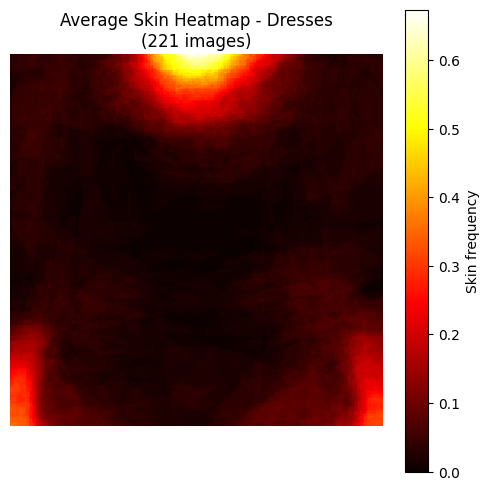


Processing folder: Sweatshirts_Hoodies


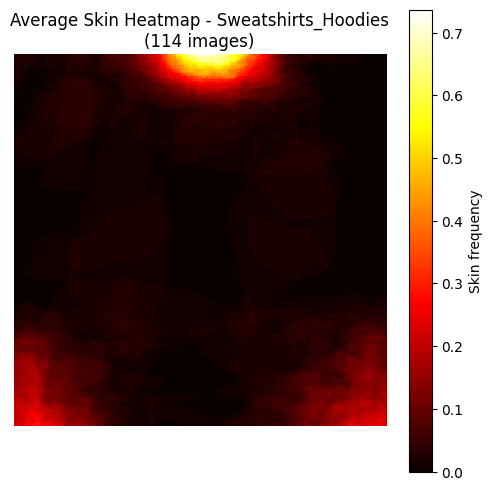


Processing folder: Cardigans


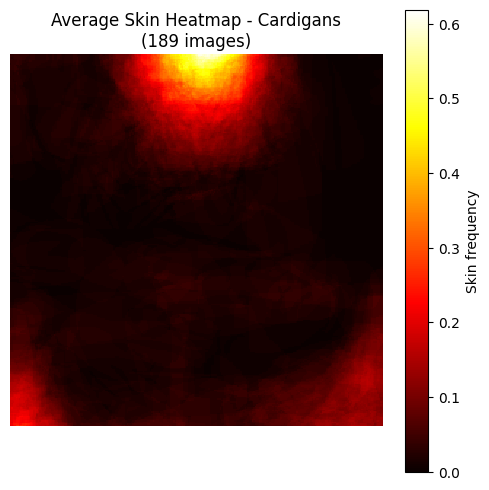


Processing folder: Blouses_Shirts


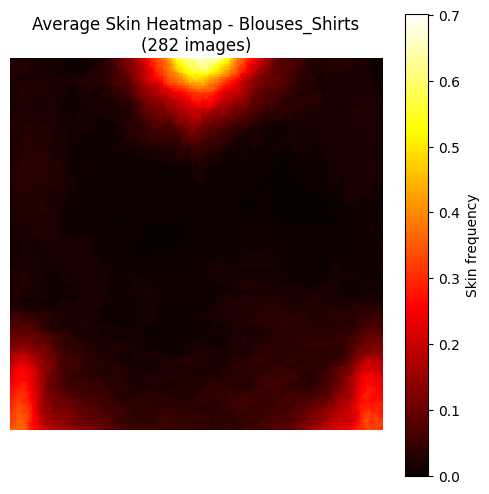


Processing folder: Rompers_Jumpsuits


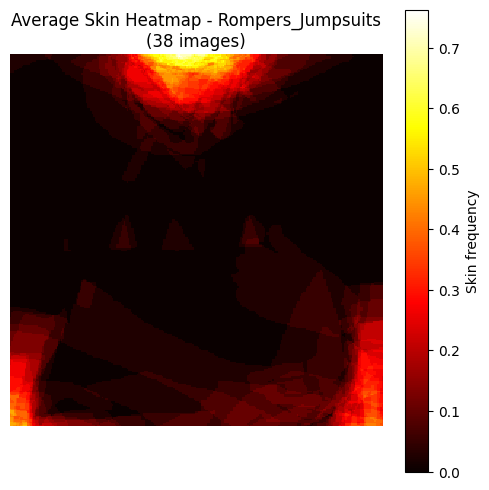


Processing folder: Tees_Tanks


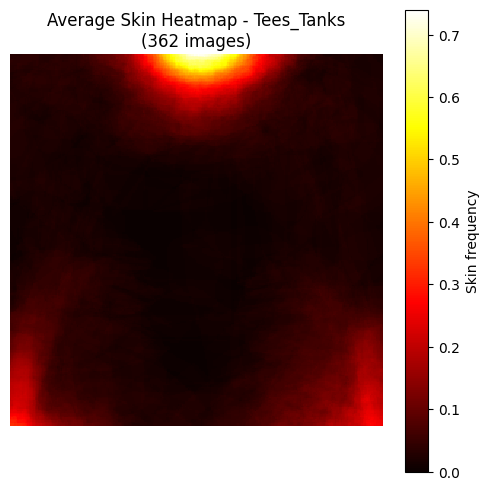


Processing folder: Jackets_Coats


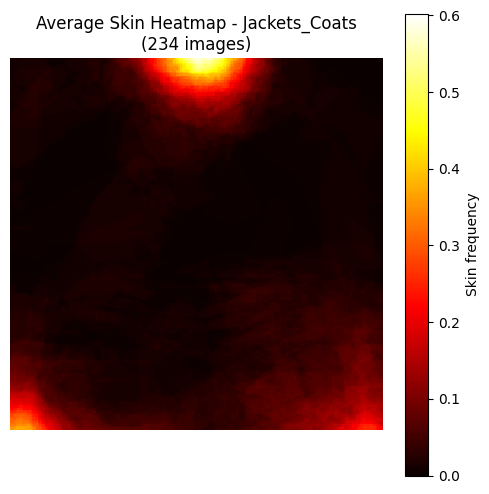


Processing folder: Pants


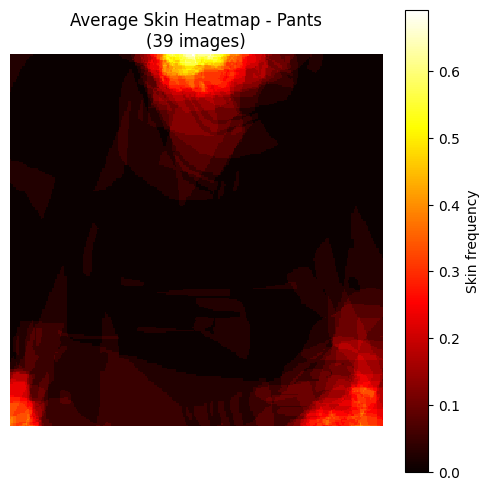


Processing folder: Sweaters


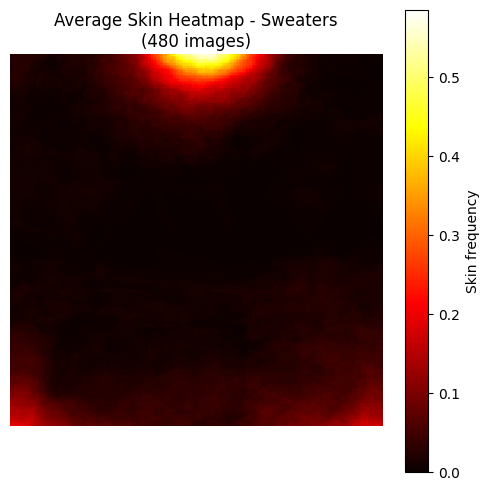


Processing folder: Graphic_Tees


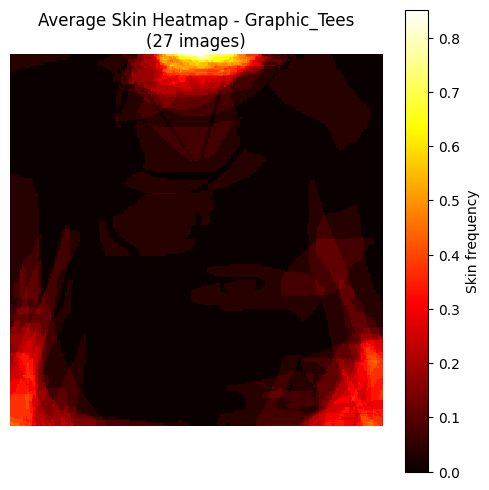


Processing folder: Skirts


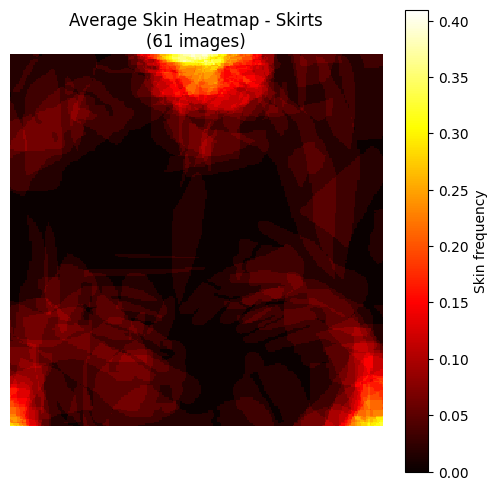


Processing folder: Shorts


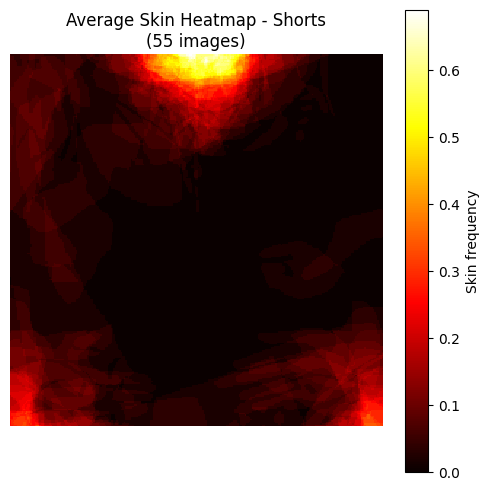


Processing folder: Denim


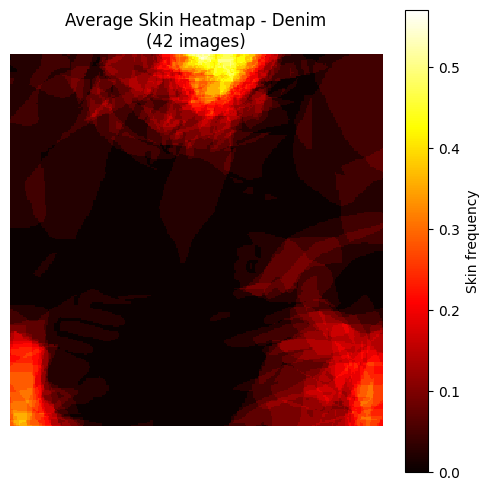


Processing folder: Leggings


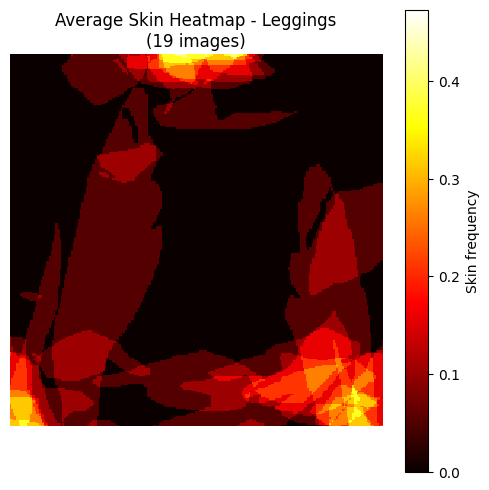

In [21]:

skin_label = 15
target_size = (256, 256)  # (width, height)

for item in os.listdir(cropped_images_destination_dir):
    folder_path = os.path.join(cropped_images_destination_dir, item)

    # skip non-folders
    if not os.path.isdir(folder_path):
        continue

    print(f"\nProcessing folder: {item}")

    all_masks = []

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)

        if not os.path.isfile(image_path):
            continue

        segm = Image.open(image_path)
        segm = np.array(segm)

        # create binary mask: 1 where pixel == 15, else 0
        skin_mask = (segm == skin_label).astype(np.float32)

        # resize mask to common size
        skin_mask_img = Image.fromarray((skin_mask * 255).astype(np.uint8))
        skin_mask_resized = skin_mask_img.resize(target_size, resample=Image.NEAREST)
        skin_mask_resized = np.array(skin_mask_resized) / 255.0 # Convert back to float32 for averaging

        # *** FIX START ***
        # Append the resized NumPy array, not the original-sized PIL Image
        all_masks.append(skin_mask_resized)
        # *** FIX END ***

    if len(all_masks) == 0:
        print(f"No valid images found in folder: {item}")
        continue

    # average mask across all images in the folder
    # Now all_masks contains arrays of the same shape, so np.mean will work
    avg_mask = np.mean(all_masks, axis=0)

    # plot heatmap
    plt.figure(figsize=(6, 6))
    plt.imshow(avg_mask, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Skin frequency')
    plt.title(f"Average Skin Heatmap - {item}\n({len(all_masks)} images)")
    plt.axis("off")
    plt.show()

Organize Modest Top images in a new folder


In [6]:
import os
import shutil

modest_tops_dir = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/modest_tops/women_modest_tops'
organized_modest_tops_dir = '/content/drive/MyDrive/PersonalProjects/modesty/Deepfashion/modest_tops/organized_women_modest_tops/'

os.makedirs(organized_modest_tops_dir, exist_ok=True)

print(f"Copying and organizing images from '{modest_tops_dir}' to '{organized_modest_tops_dir}'...")

image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')

# Iterate through items (which are expected to be subdirectories like 'Blouses_Shirts') in folder_b_path
for image_filename in os.listdir(modest_tops_dir):
    image_path = os.path.join(modest_tops_dir, image_filename)

    if image_filename.lower().endswith(image_extensions):
      try:

        extracted_clothing_type = image_filename.split('-')[1]

        # create subdirectories
        target_subdirectory_path = os.path.join(organized_modest_tops_dir, extracted_clothing_type)
        os.makedirs(target_subdirectory_path, exist_ok=True)

        destination_file_path = os.path.join(target_subdirectory_path, image_filename)

        shutil.copy2(image_path, destination_file_path)
        print(f"Copied '{image_filename}' to '{extracted_clothing_type}' folder in destination.")

      except IndexError:
        print(f"Skipping {image_filename}: Could not parse clothing type from filename. Expected format: 'PREFIX-CLOTHING_TYPE-ID...'.")
      except Exception as e:
        print(f"Error copying {image_filename}: {e}")

print("Image copying and organization process complete.")

Streaming output truncated to the last 5000 lines.
Copied 'WOMEN-Dresses-id_00005129-01_1_front.jpg' to 'Dresses' folder in destination.
Copied 'WOMEN-Sweaters-id_00002670-01_7_additional.jpg' to 'Sweaters' folder in destination.
Copied 'WOMEN-Jackets_Coats-id_00002496-01_1_front.jpg' to 'Jackets_Coats' folder in destination.
Copied 'WOMEN-Tees_Tanks-id_00005163-02_1_front.jpg' to 'Tees_Tanks' folder in destination.
Copied 'WOMEN-Sweaters-id_00006685-01_1_front.jpg' to 'Sweaters' folder in destination.
Copied 'WOMEN-Shorts-id_00007245-01_4_full.jpg' to 'Shorts' folder in destination.
Copied 'WOMEN-Tees_Tanks-id_00007542-06_7_additional.jpg' to 'Tees_Tanks' folder in destination.
Copied 'WOMEN-Tees_Tanks-id_00002523-10_1_front.jpg' to 'Tees_Tanks' folder in destination.
Copied 'WOMEN-Sweaters-id_00000958-04_1_front.jpg' to 'Sweaters' folder in destination.
Copied 'WOMEN-Dresses-id_00006803-01_4_full.jpg' to 'Dresses' folder in destination.
Copied 'WOMEN-Sweaters-id_00004787-10_1_front.j